In [5]:
import copy
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import xgboost as xgb
import numpy as np
import pandas as pd
from ax.api.client import Client

In [6]:
client = Client()
Emu_GP_Mat05 = client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/StoichModelGP/ModelGP_M05.json")
Emu_GP_Mat05.get_next_trials(max_trials=1)
Emu_GP_Mat15 = client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/StoichModelGP/ModelGP_M15.json")
Emu_GP_Mat15.get_next_trials(max_trials=1)
Emu_GP_Mat25 = client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/StoichModelGP/ModelGP_M25.json")
Emu_GP_Mat25.get_next_trials(max_trials=1)
Emu_GP_RBF = client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/StoichModelGP/ModelGP_RBF.json")
Emu_GP_RBF.get_next_trials(max_trials=1)
Emu_XGB = xgb.XGBRegressor()
Emu_XGB.load_model("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/StoichModelXG/ModelXG.json")

In [7]:
Emu_XGB.predict([[0.5,0.5]])[0]

np.float32(13.556436)

In [8]:
n = 100
feature_x = np.linspace(0,2,n-1)
feature_y = np.linspace(0,2,n-1)

[X, Y] = np.meshgrid(feature_x, feature_y)
[X,Y]

Z_GP_Mat05 = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_Mat05[row][column] = Emu_GP_Mat05.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]

Z_GP_Mat15 = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_Mat15[row][column] = Emu_GP_Mat15.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]

Z_GP_Mat25 = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_Mat25[row][column] = Emu_GP_Mat25.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]

Z_GP_RBF = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_RBF[row][column] = Emu_GP_RBF.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]

Z_XGB = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_XGB[row][column] = Emu_XGB.predict(([[X[row][column],Y[row][column]]]))[0]

Zs = [Z_GP_Mat05,Z_GP_Mat15,Z_GP_Mat25,Z_GP_RBF,Z_XGB]

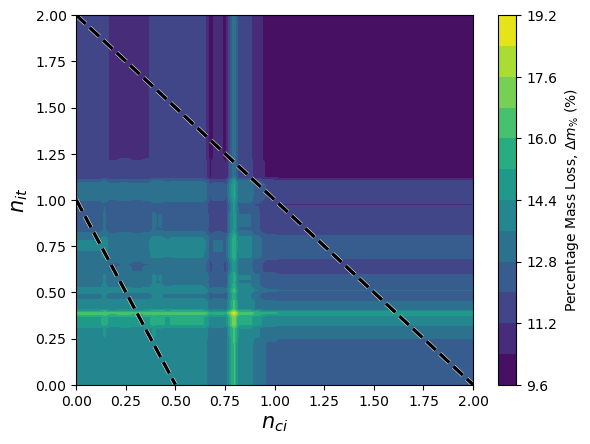

In [9]:
# e.g. XGB
fig, ax = plt.subplots(1, 1)
cf = ax.contourf(X, Y, Z_XGB, levels=10)
ax.set_xlabel(r"$n_{ci}$",fontsize=15)
ax.set_ylabel(r"$n_{it}$",fontsize=15)
ax.plot([0,2],[2,0],c="black",label="Bounds",linestyle="dashed",lw=2.5,path_effects=[pe.Stroke(linewidth=3.2, foreground='white'), pe.Normal()])
ax.plot([0,0.5],[1,0],c="black",linestyle="dashed",lw=2.5,path_effects=[pe.Stroke(linewidth=3.2, foreground='white'), pe.Normal()])
cbar = plt.colorbar(cf,label=r"Percentage Mass Loss, $\Delta m_{\%}$ (%)")

In [10]:
MaxZValues_lis = []
MinZValies_lis = []
for Z in Zs:
    MaxZValues_lis.append(np.max(Z))
    MinZValies_lis.append(np.min(Z))
MaxValueSeen = np.max(MaxZValues_lis)
MinValueSeen = np.min(MinZValies_lis)
print(MaxValueSeen)
print(MinValueSeen)

18.626216888427734
9.99621295928955


In [11]:
# decimalplaces = 2
# accordingvalue = 0.01
# MaxValueSeenRoundedUp = round(MaxValueSeen,2)
# MinValueSeenRoundedDown = round(MinValueSeen,2)-accordingvalue
# print(MaxValueSeenRoundedUp)
# print(MinValueSeenRoundedDown)
# NoOfLevels = 10
# Levels = np.linspace(MinValueSeenRoundedDown,MaxValueSeenRoundedUp,NoOfLevels)
# print(Levels)

In [12]:
Levels = np.linspace(9.5,18.5,10)

In [18]:
EmulatorNames = ["GP-Mat-05",
                 "GP-Mat-15",
                 "GP-Mat-25",
                 "GP-Rbf",
                 "Xgb"]

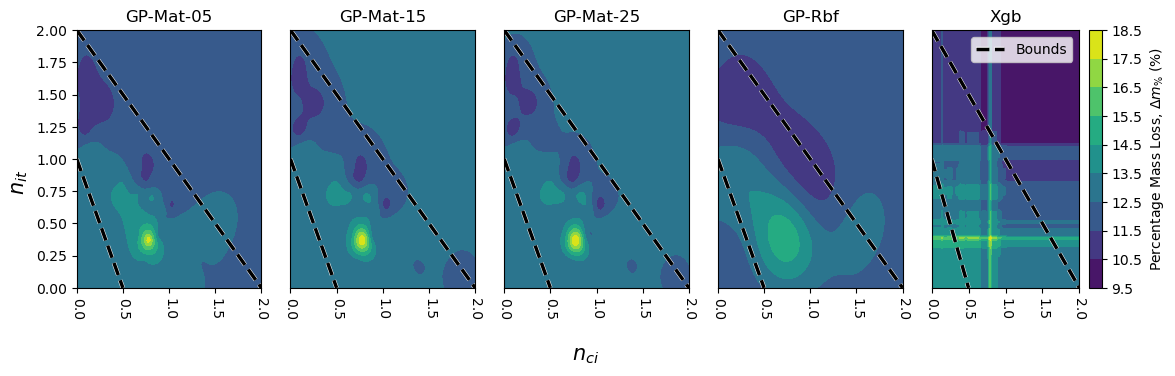

In [ ]:
fig, ax = plt.subplots(1, 5)

colors = []
levels = []

for i in range(0,5):
    ax[i].set_title(EmulatorNames[i])
    cf = ax[i].contourf(X,Y,Zs[i],levels=Levels)
    ax[i].set_xlim(0,2)
    ax[i].set_ylim(0,2)
    labels = np.linspace(0,2,5)
    ax[i].set_xticks(labels)
    ax[i].set_xticklabels(labels,rotation=-90)
    ax[i].plot()
    ax[i].plot([0,2],[2,0],c="black",label="Bounds",linestyle="dashed",lw=2.5,path_effects=[pe.Stroke(linewidth=3.2, foreground='white'), pe.Normal()])
    ax[i].plot([0,0.5],[1,0],c="black",linestyle="dashed",lw=2.5,path_effects=[pe.Stroke(linewidth=3.2, foreground='white'), pe.Normal()])
    if i > 0:
        ax[i].set_yticks([])
        if i == 4:
            ax[i].legend(loc='upper right')
            cbar = plt.colorbar(cf,label=r"Percentage Mass Loss, $\Delta m_{\%}$ (%)")

fig.supxlabel(r"$n_{ci}$",fontsize=15)
fig.supylabel(r"$n_{it}$",fontsize=15)

plt.gcf().set_size_inches(12, 3.75)
plt.tight_layout()
plt.savefig(fname='EmulatedSpaces.png',dpi=1000,format='png')